# Error Analysis for Tweet Transformer Model prediction 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from pathlib import Path 
import os

base_path = Path.cwd().parent

sns.set_theme()

In [2]:
distilbert_path = base_path/"data"/"distillbert_pred_df.csv"
bert_path = base_path/"data"/"bert_pred_df.csv"
roberta_path = base_path/"data"/"roberta_pred_df.csv"

distilbert = pd.read_csv(distilbert_path, usecols=["Target", "Text", "prediction", "probability"])
bert = pd.read_csv(bert_path, usecols=["Target", "Text", "prediction", "probability"])
roberta = pd.read_csv(roberta_path, usecols=["Target", "Text", "prediction", "probability"])

In [3]:
distilbert.head(2)

,Target,Text,prediction,probability
0,0,I wish my clients didn't use Microsoft product...,0,"[0.99395751953125, 0.006042419001460075]"
1,0,:: the outdoors and I don't mix; damn allergie...,0,"[0.9632536172866821, 0.03674633428454399]"


In [4]:
bert.head(2)

,Target,Text,prediction,probability
0,0,I wish my clients didn't use Microsoft product...,0,"[0.9866746068000793, 0.01332536619156599]"
1,0,:: the outdoors and I don't mix; damn allergie...,0,"[0.9753214120864868, 0.024678584188222885]"


In [5]:
roberta.head(2)

,Target,Text,prediction,probability
0,0,I wish my clients didn't use Microsoft product...,0,"[0.9855583906173706, 0.01444158609956503]"
1,0,:: the outdoors and I don't mix; damn allergie...,0,"[0.9826447367668152, 0.017355315387248993]"


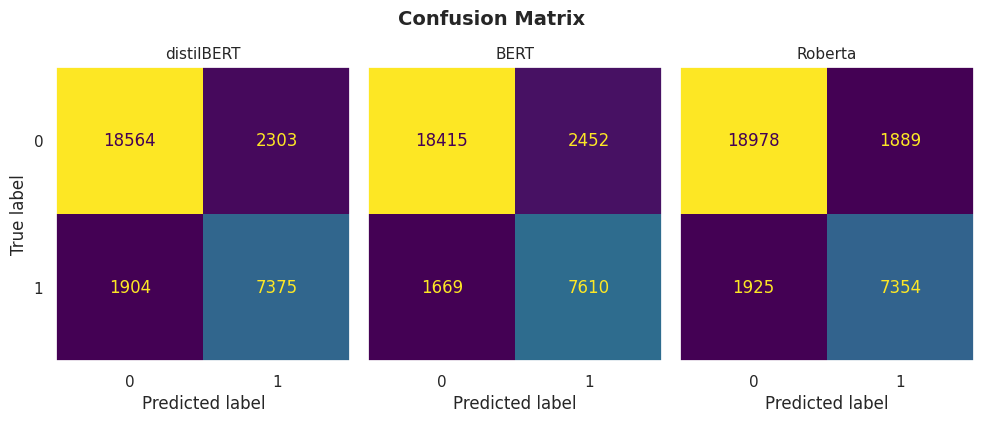

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(10,4), layout="tight", sharey=True)

disp1 = ConfusionMatrixDisplay.from_predictions(distilbert["Target"], distilbert["prediction"], 
                                               labels=[0,1],
                                              colorbar=False,
                                              ax=ax[0])
ax[0].set_title("distilBERT", fontsize=11)
ax[0].grid(False)

disp2 = ConfusionMatrixDisplay.from_predictions(bert["Target"], bert["prediction"], 
                                               labels=[0,1],
                                              colorbar=False,
                                              ax=ax[1])
ax[1].set_title("BERT", fontsize=11)
ax[1].grid(False)
ax[1].set_ylabel("")

disp3 = ConfusionMatrixDisplay.from_predictions(roberta["Target"], roberta["prediction"], 
                                               labels=[0,1],
                                              colorbar=False,
                                              ax=ax[2])
ax[2].set_title("Roberta", fontsize=11)
ax[2].set_ylabel("")
ax[2].grid(False)

plt.suptitle("Confusion Matrix", fontsize=14, fontweight="bold")
plt.show()

In [7]:
distilbert_clf_report = classification_report(distilbert["Target"], distilbert["prediction"], labels=[0,1])
print("++++++ distilBERT ++++++\n")
print(distilbert_clf_report)

++++++ distilBERT ++++++

              precision    recall  f1-score   support

           0       0.91      0.89      0.90     20867
           1       0.76      0.79      0.78      9279

    accuracy                           0.86     30146
   macro avg       0.83      0.84      0.84     30146
weighted avg       0.86      0.86      0.86     30146



In [8]:
bert_clf_report = classification_report(bert["Target"], bert["prediction"], labels=[0,1])
print("++++++ BERT ++++++\n")
print(bert_clf_report)

++++++ BERT ++++++

              precision    recall  f1-score   support

           0       0.92      0.88      0.90     20867
           1       0.76      0.82      0.79      9279

    accuracy                           0.86     30146
   macro avg       0.84      0.85      0.84     30146
weighted avg       0.87      0.86      0.86     30146



In [9]:
roberta_clf_report = classification_report(roberta["Target"], roberta["prediction"], labels=[0,1])
print("++++++ ROBERTA ++++++\n")
print(roberta_clf_report)

++++++ ROBERTA ++++++

              precision    recall  f1-score   support

           0       0.91      0.91      0.91     20867
           1       0.80      0.79      0.79      9279

    accuracy                           0.87     30146
   macro avg       0.85      0.85      0.85     30146
weighted avg       0.87      0.87      0.87     30146



##### overview
The tuned transformer models performed similary in the test dataset. Roberta tuned model achieved a higher accuracy by 1% and higher precision for the class 1 label than the other two models.  BERT tuned model however, achieved a higher recall for the class 1 label than all other models.  

## distilBERT Models Error Analysis

In [10]:
distilbert["total_words"] = distilbert["Text"].apply(lambda x: len(x.split()))
distilbert['total_exclaim'] = distilbert["Text"].apply(lambda x: len(re.findall(r"!", x)))
distilbert["num_xters"] = distilbert["Text"].apply(lambda x: len(re.findall(r"[^\s]", x)))
distilbert["prediction"].value_counts(normalize=True)

prediction
0    0.678962
1    0.321038
Name: proportion, dtype: float64

In [11]:
distilbert.head()

,Target,Text,prediction,probability,total_words,total_exclaim,num_xters
0,0,I wish my clients didn't use Microsoft product...,0,"[0.99395751953125, 0.006042419001460075]",21,0,112
1,0,:: the outdoors and I don't mix; damn allergie...,0,"[0.9632536172866821, 0.03674633428454399]",10,0,42
2,0,...gaaaah! change is good.. i guess.,0,"[0.5290113687515259, 0.4709886610507965]",6,1,31
3,1,@THE_REAL_SHAQ hi there! Are u talking to us l...,1,"[0.08403056114912033, 0.9159694910049438]",17,1,76
4,0,Im eating all my stock of chocolates and stayi...,0,"[0.502058207988739, 0.4979418218135834]",22,1,91


In [12]:
def unpack(text):
    x = text.str.strip("[]")
    x = x.str.split(",")
    return list(x)
    
distilbert[["probability"]] = distilbert[["probability"]].apply(unpack)

distilbert[['neg_prob', 'pos_prob']] = distilbert["probability"].apply(pd.Series)

distilbert = distilbert.drop("probability", axis=1)

In [13]:
distilbert["target_pred_match"] = distilbert["Target"].eq(distilbert['prediction']).apply(int)

distilbert["word_bins"], interval = pd.cut(distilbert["total_words"], bins=3, labels=range(1, 4), retbins=True)

print(interval)

distilbert.groupby("word_bins")["target_pred_match"].mean().reset_index()

[ 0.965      12.66666667 24.33333333 36.        ]


,word_bins,target_pred_match
0,1,0.869943
1,2,0.851096
2,3,0.849089


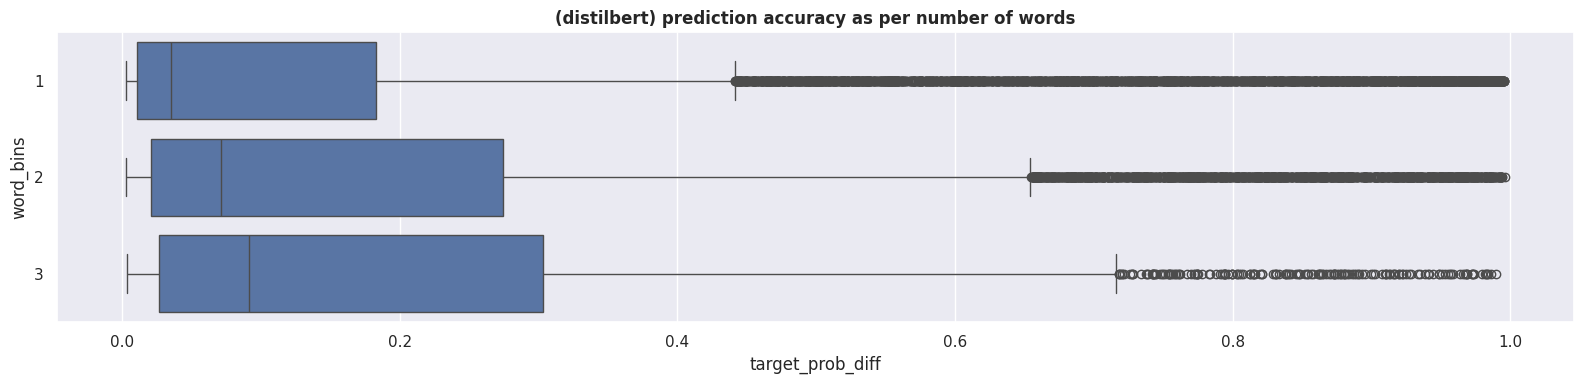

In [14]:
distilbert["target_prob_diff"] = abs(distilbert["Target"] - distilbert["pos_prob"].astype(float))

fig, ax = plt.subplots(1, 1, figsize=[16, 4], layout='tight')
sns.boxplot(data=distilbert, y="word_bins", x="target_prob_diff", ax=ax)
ax.set_title("(distilbert) prediction accuracy as per number of words", fontsize=12, fontweight='bold')
plt.show()

#### overview
The word bins show that the prediction accuracy is similar across the three word bins. This therefore means that the accuracy is similar regardless of the total number of words used in the tweet.    

The target probability difference box plots show that tweets with fewer words(< 15 words), have higher probabilities close to the target label and as such are more confident predictions than for tweets with higher number of words. 

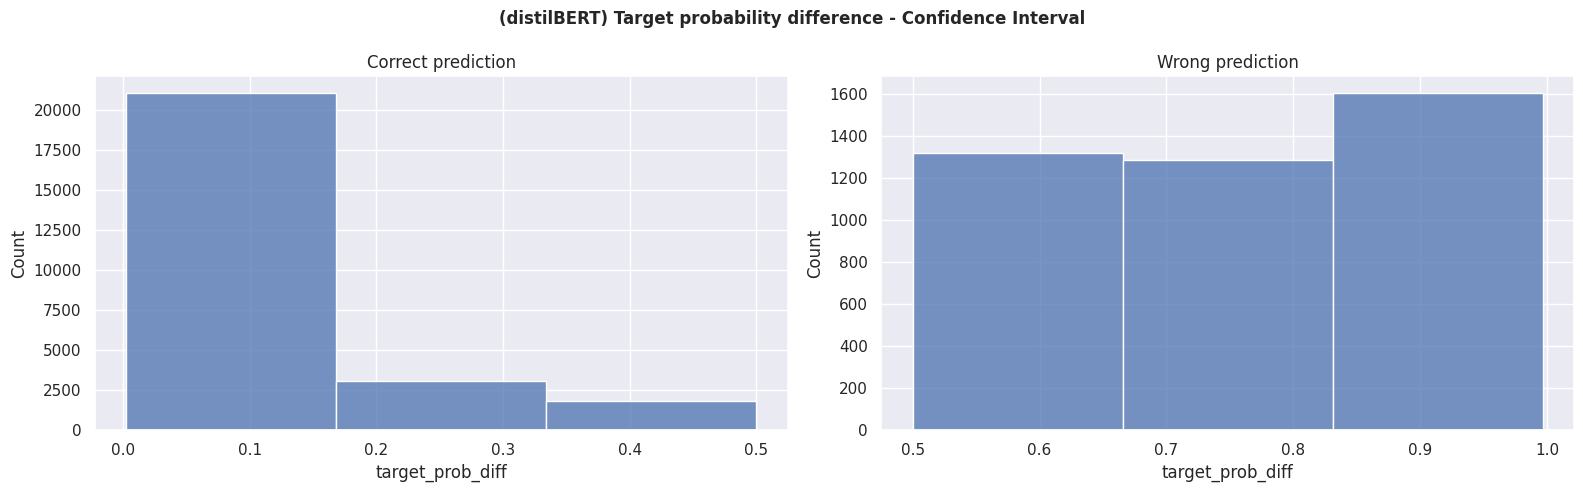

In [15]:
## inspecting distribution of the target probability differences 

target_prediction_match = distilbert.groupby('target_pred_match')
correct_pred = target_prediction_match.get_group(1)
wrong_pred = target_prediction_match.get_group(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[16, 5], layout='tight')
plt.suptitle('(distilBERT) Target probability difference - Confidence Interval', fontsize=12, fontweight="bold")
sns.histplot(data=correct_pred, x="target_prob_diff", ax=ax1, bins=3)
ax1.set_title("Correct prediction")
sns.histplot(data=wrong_pred, x="target_prob_diff", ax=ax2, bins=3)
ax2.set_title("Wrong prediction")
plt.show()

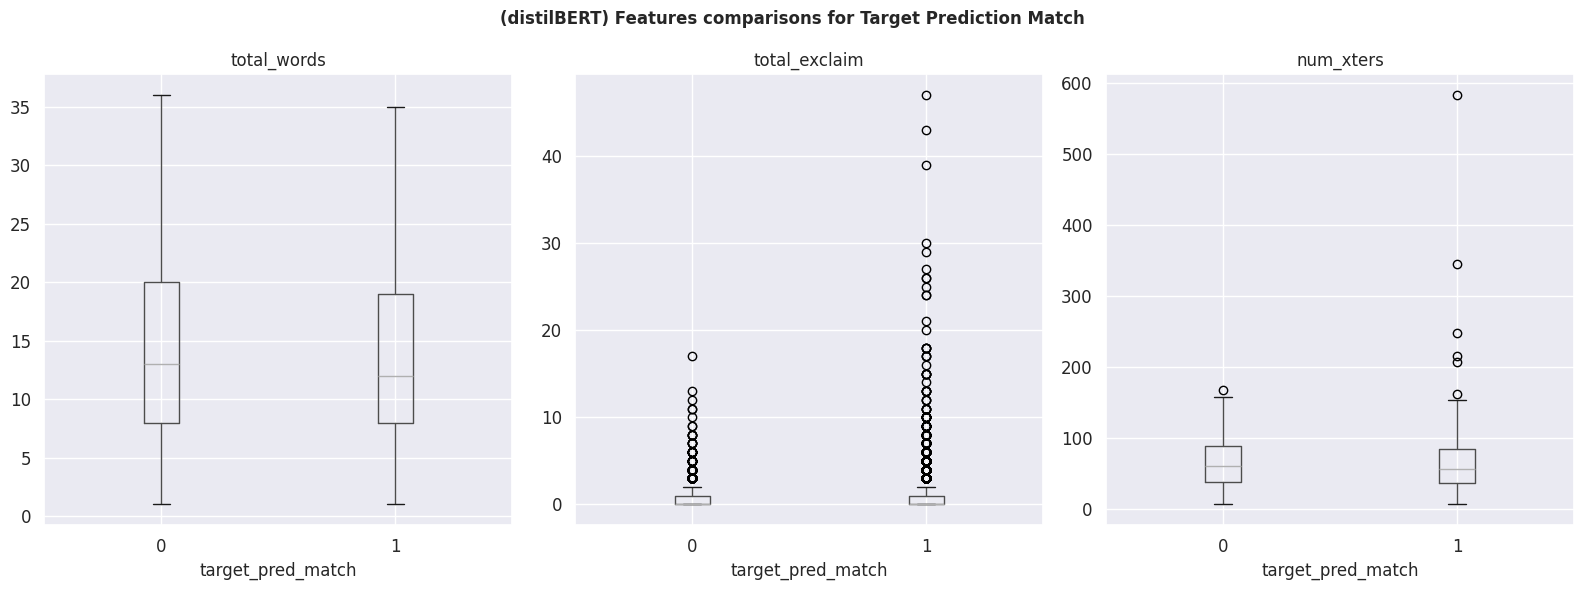

In [16]:
fig, ax = plt.subplots(1, 3, figsize=[16, 6], layout='tight',)

distilbert.boxplot(column=["total_words", "total_exclaim", "num_xters"],
                by="target_pred_match", 
                ax = ax, sharey=False, sharex=False,
                fontsize='medium',
                rot=0.3, grid=True,
               )
plt.suptitle('(distilBERT) Features comparisons for Target Prediction Match', fontweight='bold', fontsize=12)
plt.show()

##### overview
The correctly predicted tweets by the distilbert model show high confidence predictions for majority (>60%) of the test dataset.  On the otherhand, there are some high confidence wrong predictions also where the probability exceeds 0.7 (70%).  I will inspect these high confident wrong predictions to see if i can gain some insights  

The boxplots comparisons of the total words, exclaim and number of characters plotted by target prediction match indicate that the distribution of the dataset is consistent for the entire dataset. 

#### Inspecting high confident wrong predictions

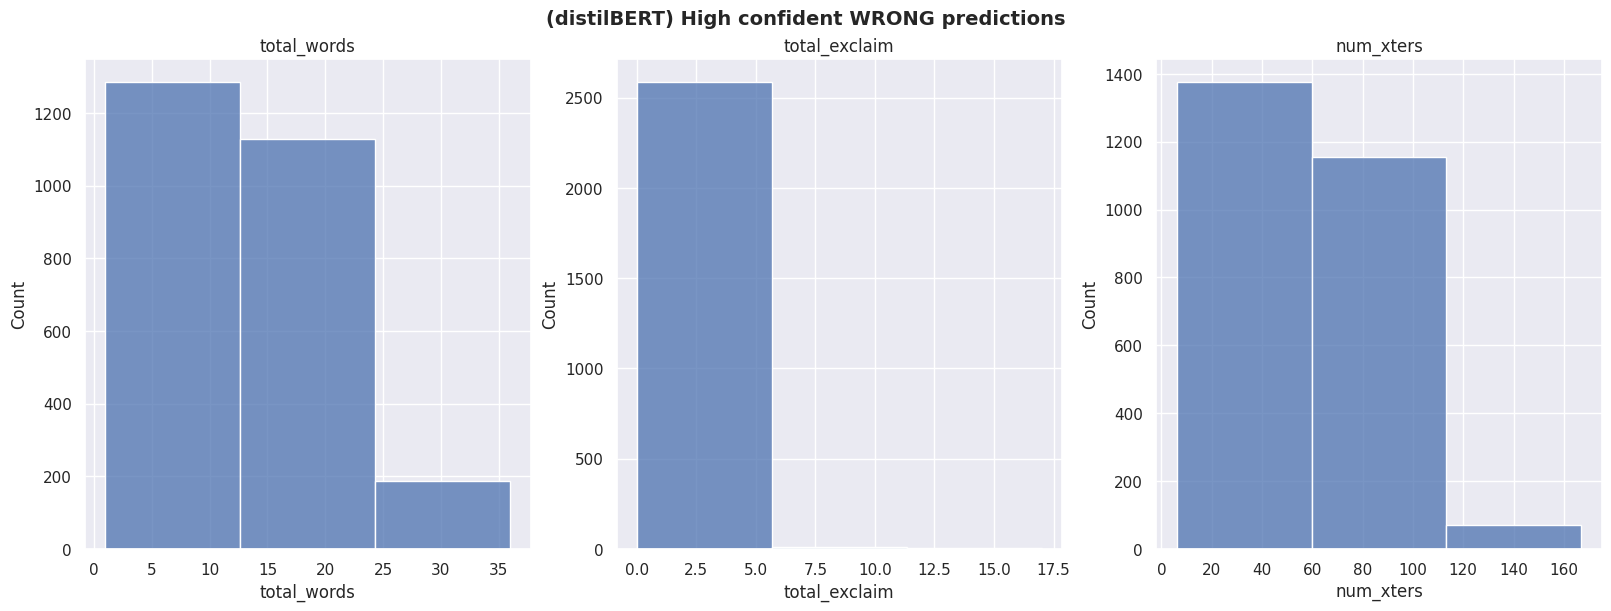

In [17]:
high_confidence_wrong_pred = distilbert.loc[distilbert["target_prob_diff"] >=0.7]

fig = plt.figure(figsize=[16, 6], layout="constrained")
features = ["total_words", "total_exclaim", "num_xters"] 

for idx, feature in zip(range(1, len(features)+1), features):
    ax = plt.subplot(1, 3, idx)
    sns.histplot(data=high_confidence_wrong_pred, x=feature, ax=ax, bins=3 )
    ax.set_title(feature)

plt.suptitle('(distilBERT) High confident WRONG predictions', fontsize=14, fontweight='bold')
plt.show()

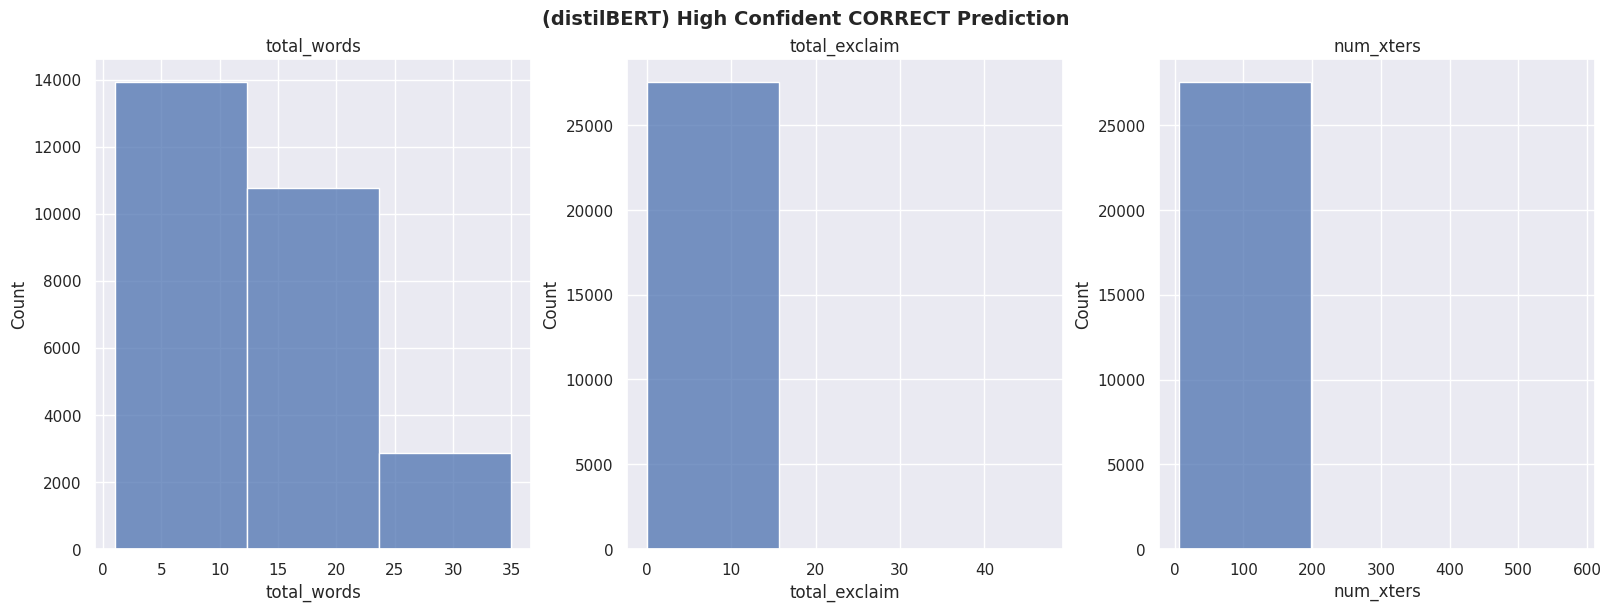

In [18]:
high_confident_correct_pred = distilbert.loc[distilbert["target_prob_diff"] <=0.7]

fig = plt.figure(figsize=[16, 6], layout="constrained")
features = ["total_words", "total_exclaim", "num_xters"] 

for idx, feature in zip(range(1, len(features)+1), features):
    ax = plt.subplot(1, 3, idx)
    sns.histplot(data=high_confident_correct_pred, x=feature, ax=ax, bins=3 )
    ax.set_title(feature)

plt.suptitle('(distilBERT) High Confident CORRECT Prediction', fontsize=14, fontweight='bold')
plt.show()

In [19]:
agg_features = ["total_words", "total_exclaim", "num_xters"]

correct_agg  = high_confident_correct_pred[agg_features].agg(np.mean)
wrong_agg = high_confidence_wrong_pred[agg_features].agg(np.mean)
average_comparison_df = pd.concat([correct_agg, wrong_agg], axis=1).rename(columns={0:"correct_pred_avg", 1:"wrong_pred_avg"})
average_comparison_df


,correct_pred_avg,wrong_pred_avg
total_words,13.398221,13.404075
total_exclaim,0.547540,0.527874
num_xters,60.361735,61.116878


#### DistilBERT Prediction Performance Overview 
There is not a major difference in the feature characteristics correctly classified tweets and wrongly classified tweets. Slight differences exist however in the ranges of total exclaim and number of characters used for correct predictions against incorrect predictions as shown in their plots.  However, these differences are not distinct because the ranges of the features for incorrectly classified tweets are contained within the ranges of correctly classified tweets.  

One other feature that might be insightful is to inspect the vocabulary used for in both set of tweets using a count vectorizer. However, I do not intend to go further to investigate the vocabularies.  

Otherwise, it is sufficient to conclude that the wrongly classified tweets are model dependent rather than dataset/tweet characteristic dependent for the distilbert tuned model. 

## BERT Model Error Analysis

In [20]:
bert["total_words"] = bert["Text"].apply(lambda x: len(x.split()))
bert['total_exclaim'] = bert["Text"].apply(lambda x: len(re.findall(r"!", x)))
bert["num_xters"] = bert["Text"].apply(lambda x: len(re.findall(r"[^\s]", x)))
bert["prediction"].value_counts(normalize=True)

prediction
0    0.666224
1    0.333776
Name: proportion, dtype: float64

In [21]:
bert[["probability"]] = bert[["probability"]].apply(unpack)

bert[['neg_prob', 'pos_prob']] = bert["probability"].apply(pd.Series)

bert = bert.drop("probability", axis=1)

bert["target_pred_match"] = bert["Target"].eq(bert['prediction']).apply(int)

bert["word_bins"], interval = pd.cut(bert["total_words"], bins=3, labels=range(1, 4), retbins=True)

print(interval)

bert.groupby("word_bins")["target_pred_match"].mean().reset_index()

[ 0.965      12.66666667 24.33333333 36.        ]


,word_bins,target_pred_match
0,1,0.875074
1,2,0.852678
2,3,0.843886


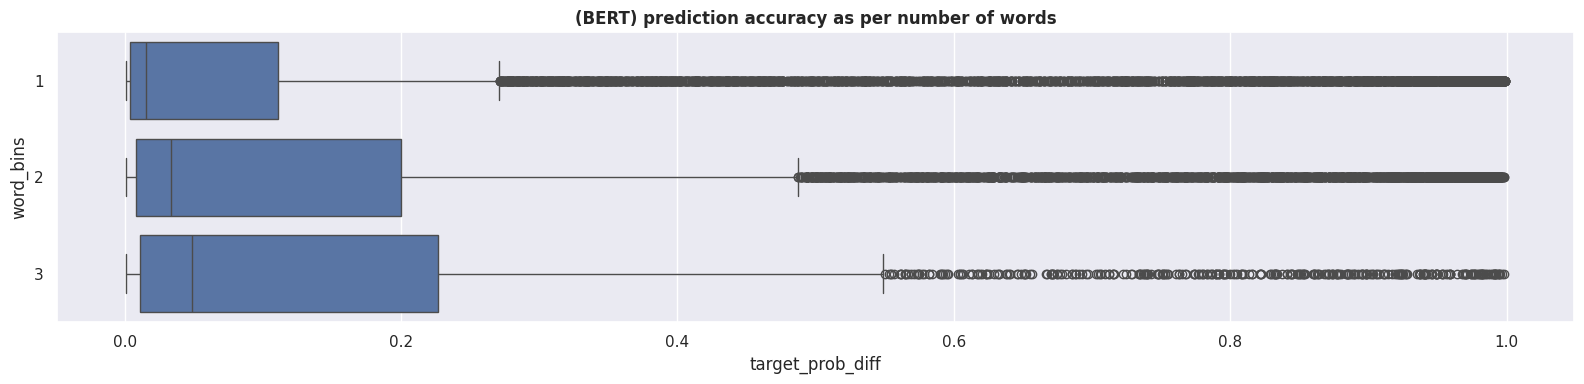

In [22]:
bert["target_prob_diff"] = abs(bert["Target"] - bert["pos_prob"].astype(float))

fig, ax = plt.subplots(1, 1, figsize=[16, 4], layout='tight')
sns.boxplot(data=bert, y="word_bins", x="target_prob_diff", ax=ax)
ax.set_title("(BERT) prediction accuracy as per number of words", fontsize=12, fontweight='bold')
plt.show()


##### Overview
For the BERT tuned model, the lower the number of words in a tweet, the higher the prediction confidence of the model. This is a significant difference from the distilBERT model where the target_prob_diff range is nearly 0.2. 

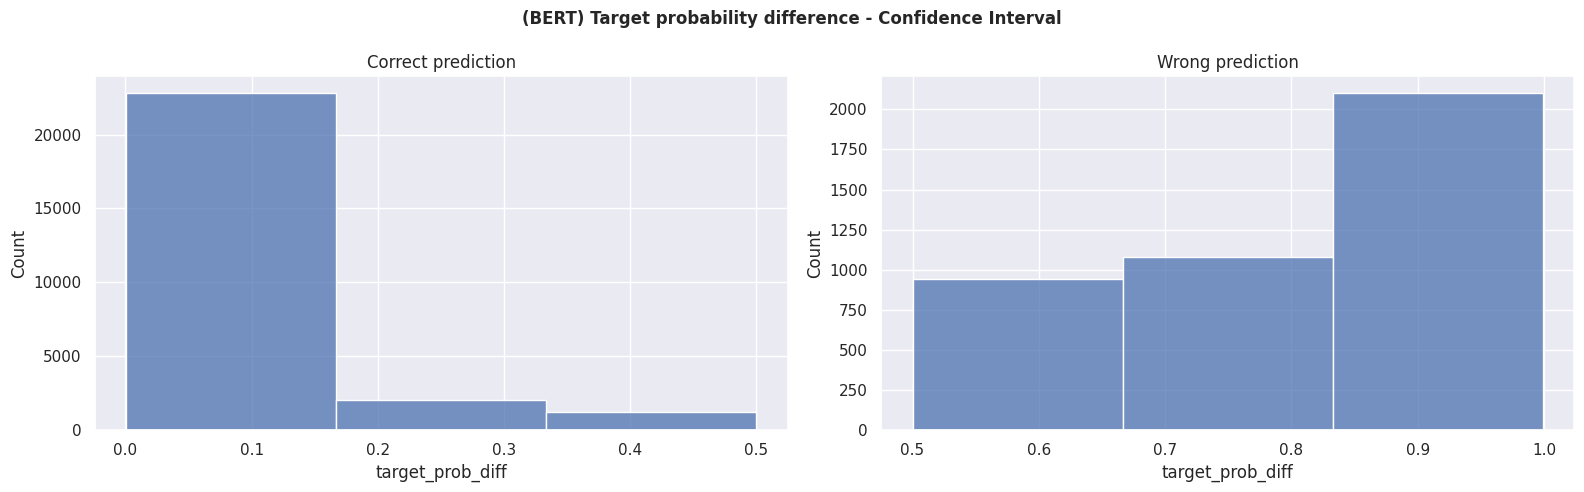

In [23]:
## inspecting distribution of the target probability differences 

target_prediction_match = bert.groupby('target_pred_match')
correct_pred = target_prediction_match.get_group(1)
wrong_pred = target_prediction_match.get_group(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[16, 5], layout='tight')
plt.suptitle('(BERT) Target probability difference - Confidence Interval', fontsize=12, fontweight="bold")
sns.histplot(data=correct_pred, x="target_prob_diff", ax=ax1, bins=3)
ax1.set_title("Correct prediction")
sns.histplot(data=wrong_pred, x="target_prob_diff", ax=ax2, bins=3)
ax2.set_title("Wrong prediction")
plt.show()

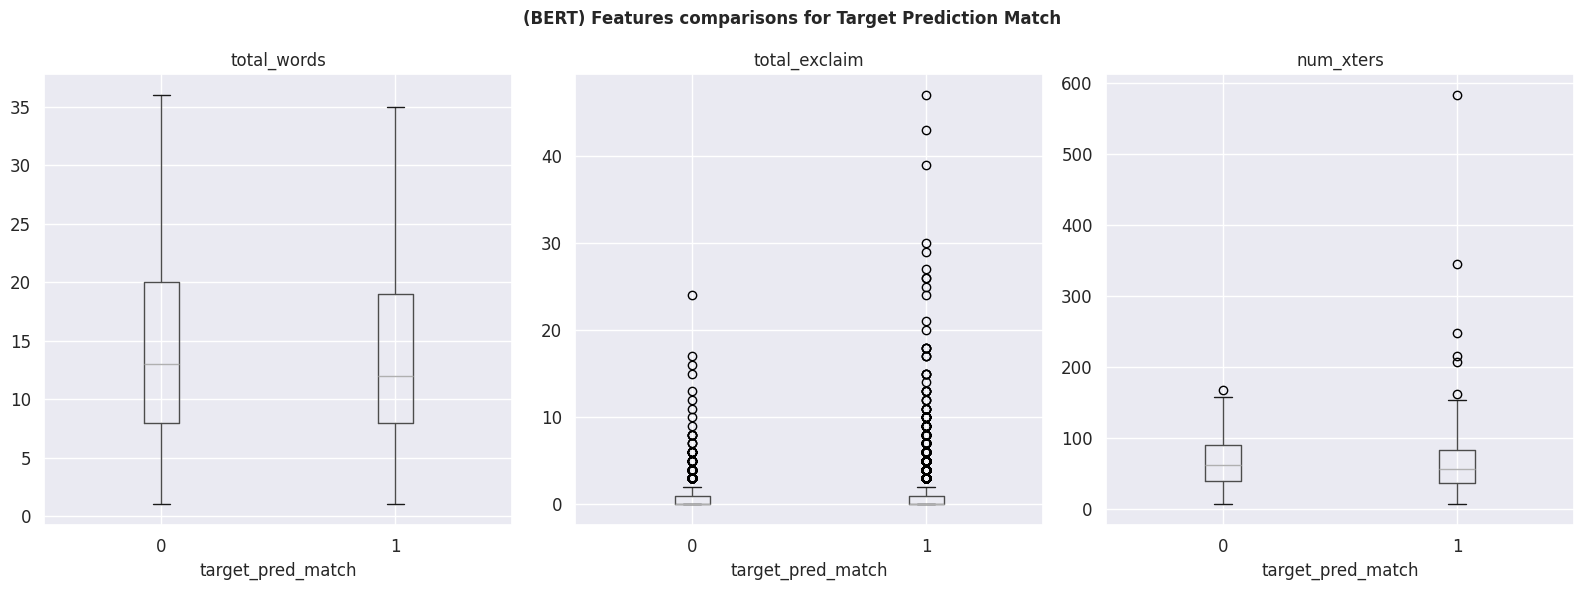

In [24]:
fig, ax = plt.subplots(1, 3, figsize=[16, 6], layout='tight',)

bert.boxplot(column=["total_words", "total_exclaim", "num_xters"],
                by="target_pred_match", 
                ax = ax, sharey=False, sharex=False,
                fontsize='medium',
                rot=0.3, grid=True,
               )
plt.suptitle('(BERT) Features comparisons for Target Prediction Match', fontweight='bold', fontsize=12)
plt.show()

##### Overview
The confidence levels for the BERT tuned model predictions are generally higher than that of the distilBERT model.  This can be seen from the histogram bin plots which are skewed both for correct and wrong predictions.  Here it can be seen that the tuned BERT model predicts with higher confidence regardless of the accuracy of the prediction. 

#### Inspecting high confident wrong prediction

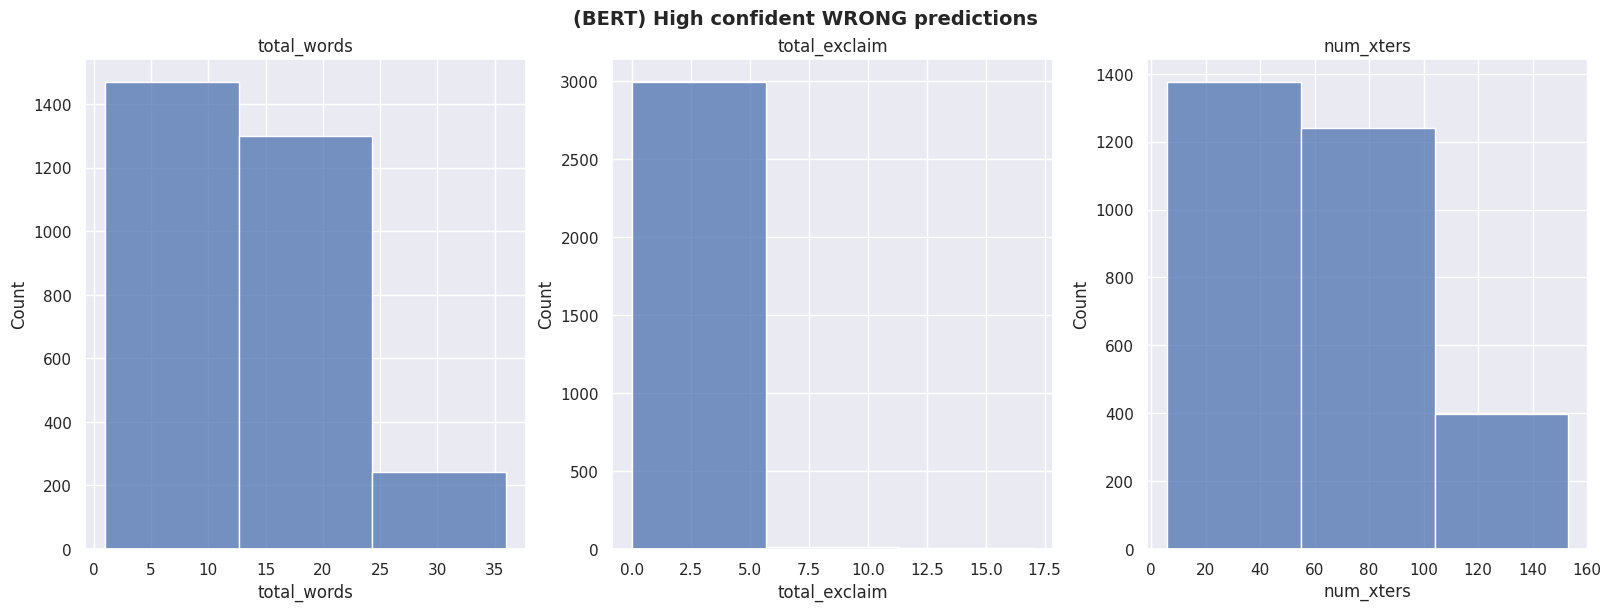

In [25]:
high_confidence_wrong_pred = bert.loc[bert["target_prob_diff"] >=0.7]

fig = plt.figure(figsize=[16, 6], layout="constrained")
features = ["total_words", "total_exclaim", "num_xters"] 

for idx, feature in zip(range(1, len(features)+1), features):
    ax = plt.subplot(1, 3, idx)
    sns.histplot(data=high_confidence_wrong_pred, x=feature, ax=ax, bins=3 )
    ax.set_title(feature)

plt.suptitle('(BERT) High confident WRONG predictions', fontsize=14, fontweight='bold')
plt.show()

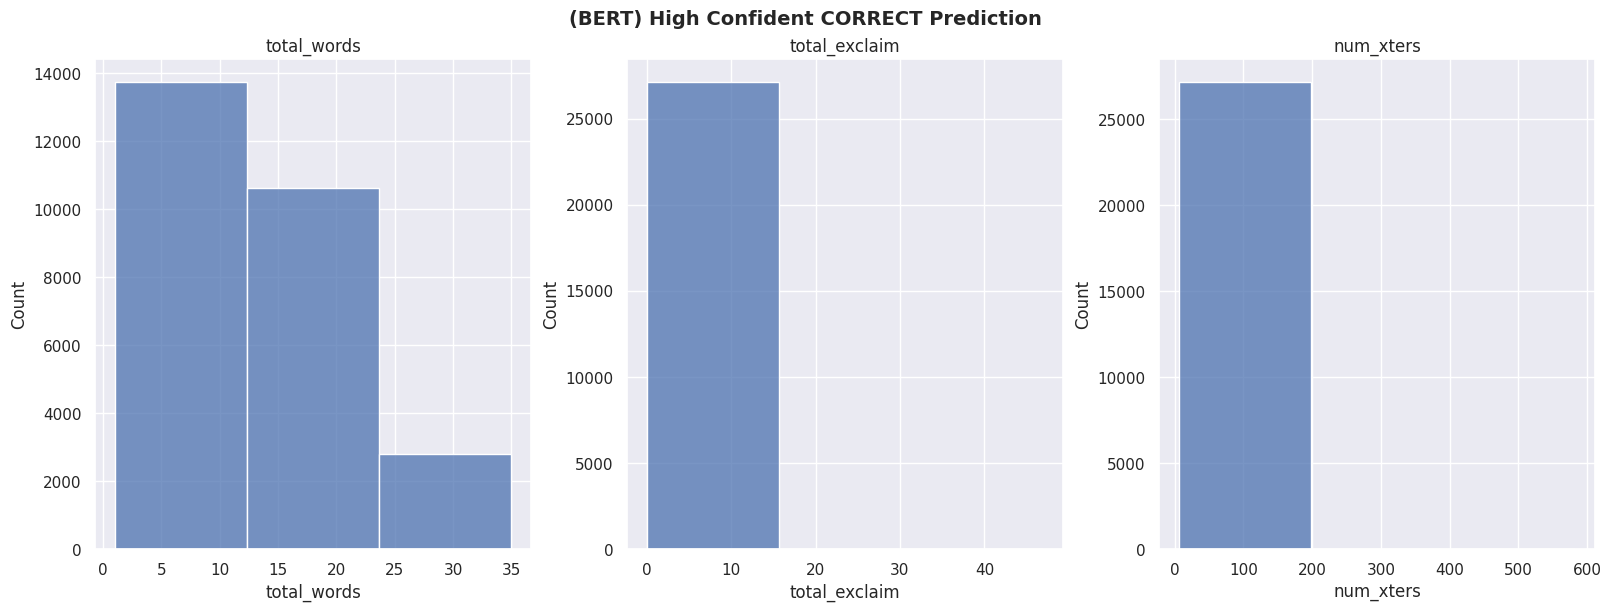

In [26]:
high_confident_correct_pred = bert.loc[bert["target_prob_diff"] <=0.7]

fig = plt.figure(figsize=[16, 6], layout="constrained")
features = ["total_words", "total_exclaim", "num_xters"] 

for idx, feature in zip(range(1, len(features)+1), features):
    ax = plt.subplot(1, 3, idx)
    sns.histplot(data=high_confident_correct_pred, x=feature, ax=ax, bins=3 )
    ax.set_title(feature)

plt.suptitle('(BERT) High Confident CORRECT Prediction', fontsize=14, fontweight='bold')
plt.show()

In [27]:
agg_features = ["total_words", "total_exclaim", "num_xters"]

correct_agg  = high_confident_correct_pred[agg_features].agg(np.mean)
wrong_agg = high_confidence_wrong_pred[agg_features].agg(np.mean)
average_comparison_df = pd.concat([correct_agg, wrong_agg], axis=1).rename(columns={0:"correct_pred_avg", 1:"wrong_pred_avg"})
average_comparison_df


,correct_pred_avg,wrong_pred_avg
total_words,13.370582,13.652174
total_exclaim,0.546346,0.541321
num_xters,60.225076,62.244275


#### BERT prediction performance overview
Just as the tuned distilBERT model, there are no major distinctions seen between the high confidence wrong predictions are the high confidence correct predictions. Therefore, the predicted wrong classes can be attributed to the model and not differences in dataset distribution. 

## RoBERTA Error Analysis

In [28]:
roberta["total_words"] = roberta["Text"].apply(lambda x: len(x.split()))
roberta['total_exclaim'] = roberta["Text"].apply(lambda x: len(re.findall(r"!", x)))
roberta["num_xters"] = roberta["Text"].apply(lambda x: len(re.findall(r"[^\s]", x)))
roberta["prediction"].value_counts(normalize=True)

prediction
0    0.693392
1    0.306608
Name: proportion, dtype: float64

In [29]:
roberta[["probability"]] = roberta[["probability"]].apply(unpack)

roberta[['neg_prob', 'pos_prob']] = roberta["probability"].apply(pd.Series)

roberta = roberta.drop("probability", axis=1)

roberta["target_pred_match"] = roberta["Target"].eq(roberta['prediction']).apply(int)

roberta["word_bins"], interval = pd.cut(roberta["total_words"], bins=3, labels=range(1, 4), retbins=True)

print(interval)

roberta.groupby("word_bins")["target_pred_match"].mean().reset_index()

[ 0.965      12.66666667 24.33333333 36.        ]


,word_bins,target_pred_match
0,1,0.879876
1,2,0.867395
2,3,0.864701


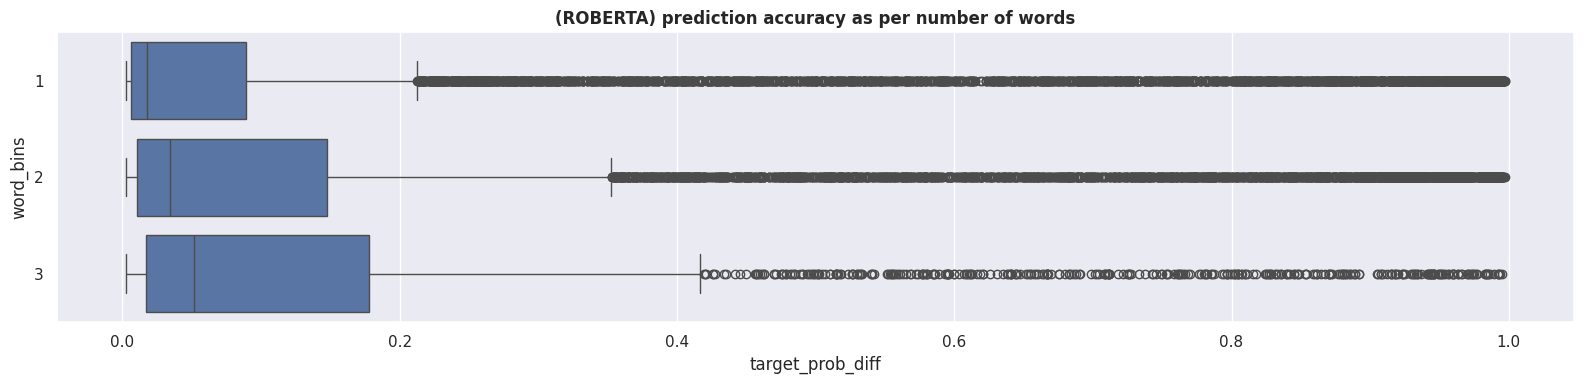

In [30]:
roberta["target_prob_diff"] = abs(roberta["Target"] - roberta["pos_prob"].astype(float))

fig, ax = plt.subplots(1, 1, figsize=[16, 4], layout='tight')
sns.boxplot(data=roberta, y="word_bins", x="target_prob_diff", ax=ax)
ax.set_title("(ROBERTA) prediction accuracy as per number of words", fontsize=12, fontweight='bold')
plt.show()


##### Overview
Roberta tuned model also achieves higher accuracy with lesser number of words as in the BERT model

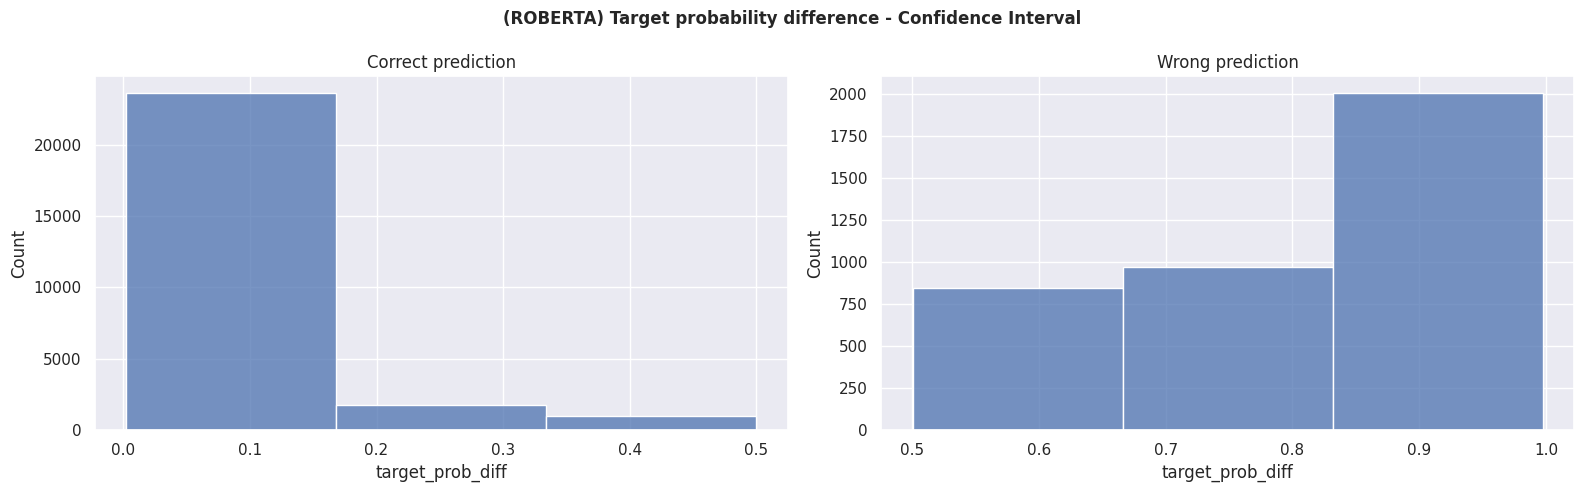

In [31]:
## inspecting distribution of the target probability differences 

target_prediction_match = roberta.groupby('target_pred_match')
correct_pred = target_prediction_match.get_group(1)
wrong_pred = target_prediction_match.get_group(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[16, 5], layout='tight')
plt.suptitle('(ROBERTA) Target probability difference - Confidence Interval', fontsize=12, fontweight="bold")
sns.histplot(data=correct_pred, x="target_prob_diff", ax=ax1, bins=3)
ax1.set_title("Correct prediction")
sns.histplot(data=wrong_pred, x="target_prob_diff", ax=ax2, bins=3)
ax2.set_title("Wrong prediction")
plt.show()

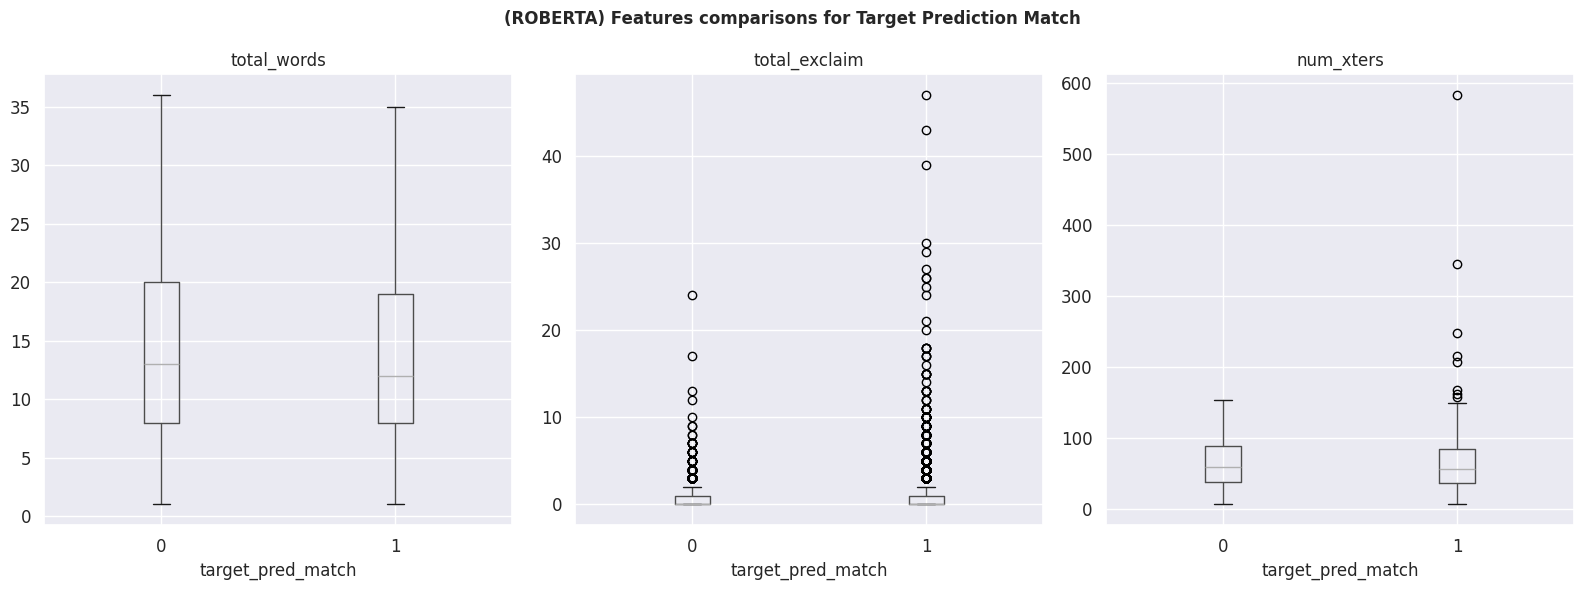

In [32]:
fig, ax = plt.subplots(1, 3, figsize=[16, 6], layout='tight',)

roberta.boxplot(column=["total_words", "total_exclaim", "num_xters"],
                by="target_pred_match", 
                ax = ax, sharey=False, sharex=False,
                fontsize='medium',
                rot=0.3, grid=True,
               )
plt.suptitle('(ROBERTA) Features comparisons for Target Prediction Match', fontweight='bold', fontsize=12)
plt.show()

##### overview 
The confidence levels for the predicted classes using the RoBERTA model are also skewed as seen from the plots and indicate that predictions by the model are made with high probability

#### Inspecting high confident wrong prediction

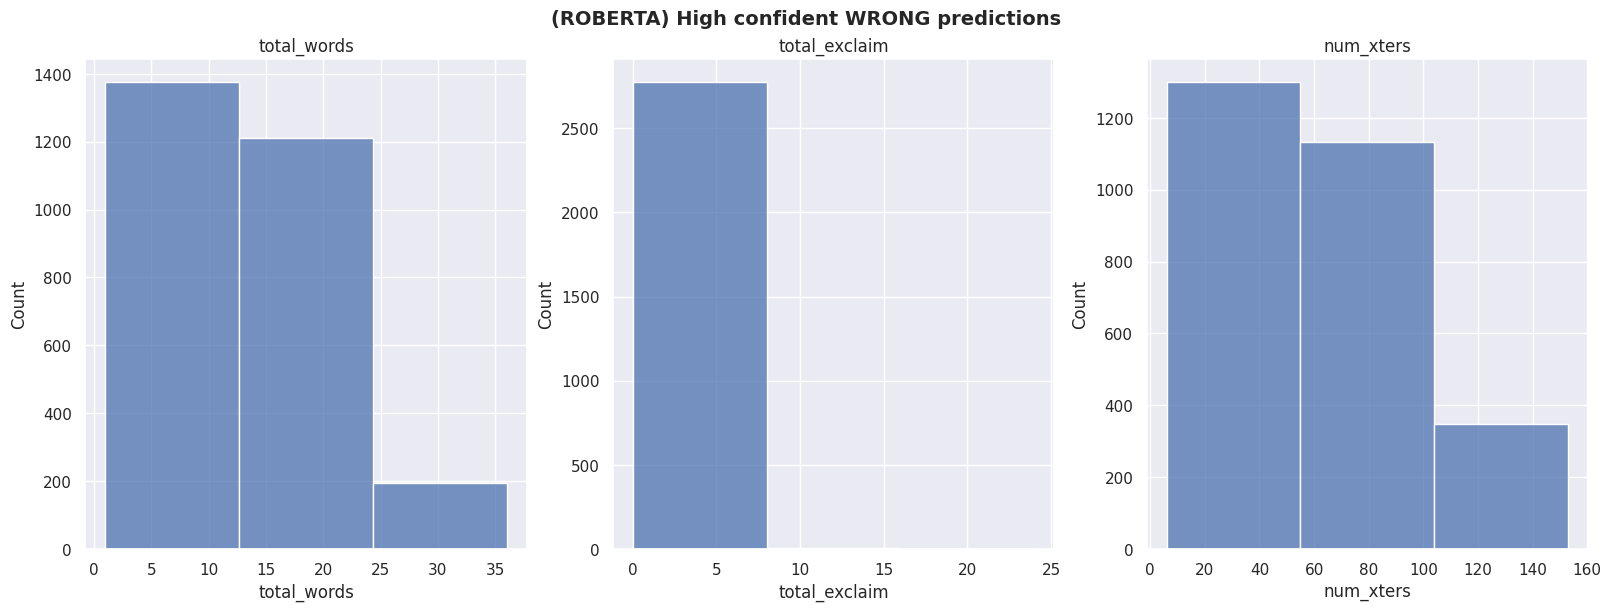

In [33]:
high_confidence_wrong_pred = roberta.loc[roberta["target_prob_diff"] >=0.7]

fig = plt.figure(figsize=[16, 6], layout="constrained")
features = ["total_words", "total_exclaim", "num_xters"] 

for idx, feature in zip(range(1, len(features)+1), features):
    ax = plt.subplot(1, 3, idx)
    sns.histplot(data=high_confidence_wrong_pred, x=feature, ax=ax, bins=3 )
    ax.set_title(feature)

plt.suptitle('(ROBERTA) High confident WRONG predictions', fontsize=14, fontweight='bold')
plt.show()

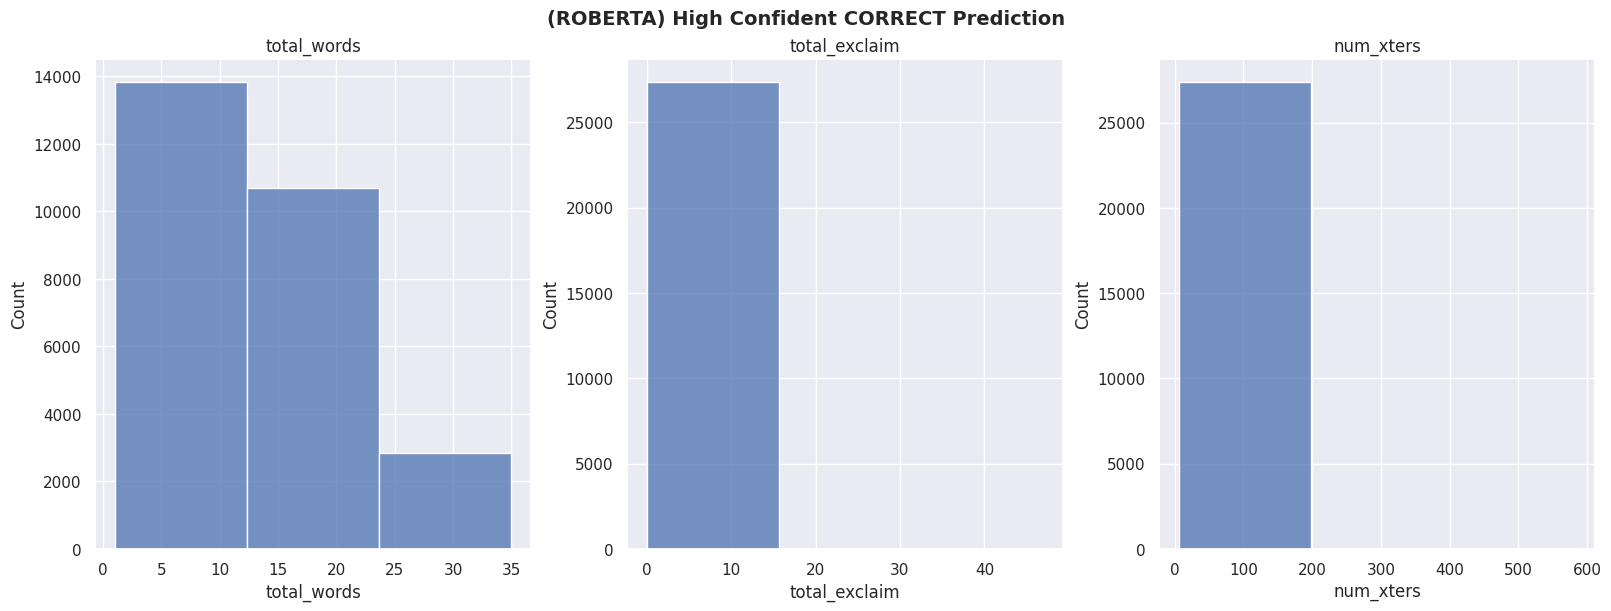

In [34]:
high_confident_correct_pred = roberta.loc[roberta["target_prob_diff"] <=0.7]

fig = plt.figure(figsize=[16, 6], layout="constrained")
features = ["total_words", "total_exclaim", "num_xters"] 

for idx, feature in zip(range(1, len(features)+1), features):
    ax = plt.subplot(1, 3, idx)
    sns.histplot(data=high_confident_correct_pred, x=feature, ax=ax, bins=3 )
    ax.set_title(feature)

plt.suptitle('(ROBERTA) High Confident CORRECT Prediction', fontsize=14, fontweight='bold')
plt.show()

In [35]:
agg_features = ["total_words", "total_exclaim", "num_xters"]

correct_agg  = high_confident_correct_pred[agg_features].agg(np.mean)
wrong_agg = high_confidence_wrong_pred[agg_features].agg(np.mean)
average_comparison_df = pd.concat([correct_agg, wrong_agg], axis=1).rename(columns={0:"correct_pred_avg", 1:"wrong_pred_avg"})
average_comparison_df


,correct_pred_avg,wrong_pred_avg
total_words,13.396733,13.418345
total_exclaim,0.546810,0.536331
num_xters,60.310970,61.567986


#### BERT prediction performance overview
The roberta tuned model is not significantly different from the BERT model. Therefore the same conclusion can be made that the dataset distribution does not affect the predicted class 

## Conclusion

The predictive performance of the three tuned transformer models were evaluated by accuracy, precision, recall and f1. The error analysis following the model predictions has shown that the misclassified texts are a result of the model performances and not the property of the dataset.  Comparisons between correctly classified tweets and incorrectly classified tweets did not show any major differences based on the number of words, number of exclaim and number of characters used in the text. 
Some subtle observances however include. 
* Higher predictive confidence was achieved by all models when the number of words in the text were less than 15.
* The BERT and RoBERTa tuned models predicted with higher probability values compared to the distillBERT model

** *Next steps*   
Evaluation of the dataset predictions on occasions where the three models wrongly classified a tweet